# fit random forest and use it for feature selection. 
- one-hot encode data (aka create dummy variables)
- test RF training and test score by max depth
- select RF depth and use it for further steps:
- calculate and save confusion matrix
- calculate feature importances using two approaches: gini impurity and permutation
  - results in two sets of most important features
- refit RF with only a subset of the most important features and display RF score by number of features

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix #plot_confusion_matrix, 
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt


In [2]:
#read data and drop columns that would generate too many dummy variables in the one-hot encoding
dat = pd.read_parquet('data/votersurvey_cleaned_noDropNA.parquet')
dat = dat.dropna()
dat = dat.drop(columns = "inputstate_2016") #creates too many dummy variables


#prepare data
y = dat["presvote16post_2016"]
X = dat.drop(columns = "presvote16post_2016")
#one-hot encode categorical data
X_oh = pd.get_dummies(X, dtype = int)
X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)

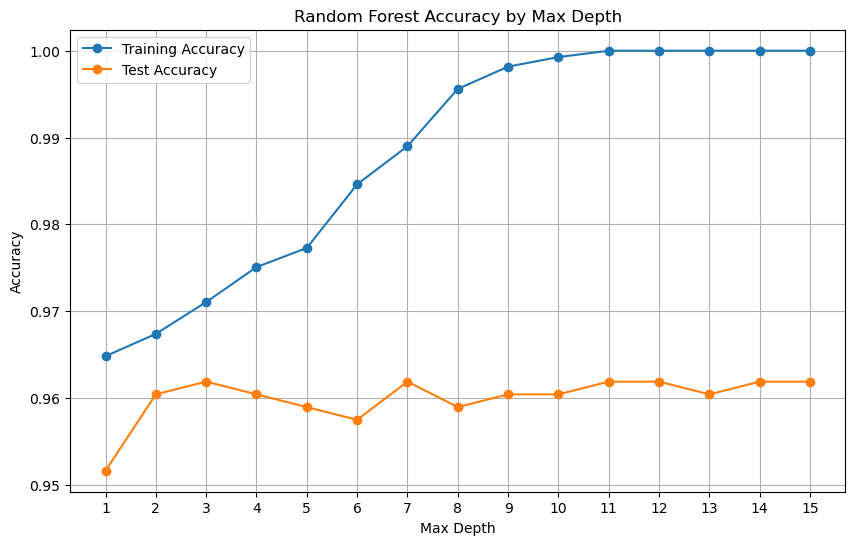

In [3]:
# test RF performance by max depth

# Initialize lists to store results
depths = list(range(1, 16))
train_accuracies = []
test_accuracies = []

# Run Random Forest for each depth
for i in depths:
    rf = RandomForestClassifier(
        n_estimators=500,
        random_state=123,
        max_depth=i,
        #max_features = 20
    )
    rf.fit(X_train_oh, y_train)

    # Store accuracies
    train_acc = rf.score(X_train_oh, y_train)
    test_acc = rf.score(X_test_oh, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    'max_depth': depths,
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(results_df['max_depth'], results_df['train_accuracy'],
         marker='o', label='Training Accuracy')
plt.plot(results_df['max_depth'], results_df['test_accuracy'],
         marker='o', label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy by Max Depth')
plt.legend()
plt.grid(True)
plt.xticks(depths)
#save figure
plt.savefig('results/RF/RF_performance_by_maxdepth_clinton_trump.png')
plt.show()



# Display the DataFrame
#print("\nResults DataFrame:")
#print(results_df)

                 precision    recall  f1-score   support

   Donald Trump       0.97      0.95      0.96       351
Hillary Clinton       0.95      0.96      0.96       331

       accuracy                           0.96       682
      macro avg       0.96      0.96      0.96       682
   weighted avg       0.96      0.96      0.96       682



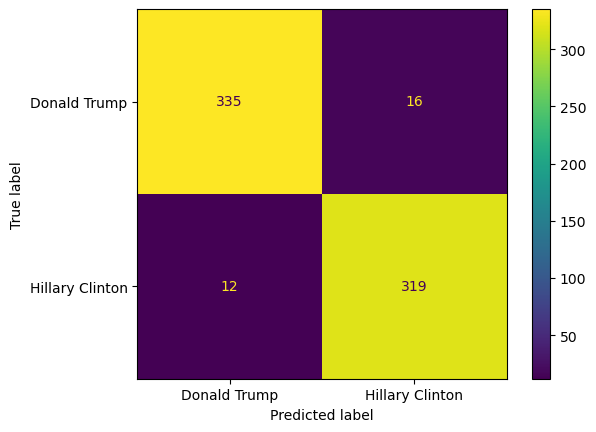

In [4]:
#choose selected maxdepth
selectedmaxdepth = 5 #no significant increase in test accuracy afterwards

# run random forest with prefered depth and create confusion matrix
rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = selectedmaxdepth)
rf.fit(X_train_oh, y_train)

y_pred = rf.predict(X_test_oh)
cmat = confusion_matrix(y_test, y_pred, labels = rf.classes_)
ConfusionMatrixDisplay(cmat, display_labels = rf.classes_).plot()

#save confmat figure
plt.savefig(f'results/RF/RF_confmat_maxdepth{selectedmaxdepth}.png')

#classification report
print(classification_report(y_test, y_pred))

## extract feature importances
based on the random forest with chosen max depth
- method 1: using mean decrease in gini impurities
- method 2: using feature permutation. I believe this is the better approach since we have high-cardinality features

### feature importance using mean decrease in gini impurities

In [5]:
#extract feature importance and regroup by dummy variable
#e. g. sum over the rows "presvote16post_2016_Hillary Clinton" and "presvote16post_2016_Donald Trump"

#this can be used for feature selection


#create df
imp = rf.feature_importances_
imp_names = rf.feature_names_in_
imp_df = pd.DataFrame({"imp" : imp, "imp_names" : imp_names})

# Extract the base name (everything before the last underscore)
imp_df["base_name"] = imp_df["imp_names"].str.rsplit('_', n=1).str[0]

# Group by base_name and sum the 'imp' values
imp_df_grouped = imp_df.groupby("base_name", as_index=False)["imp"].sum().sort_values("imp", ascending = False)
imp_df_grouped = imp_df_grouped.rename(columns = {"imp": "imp_grouped"})

imp_df_grouped.head(25)

,base_name,imp_grouped
69,healthreformbill_2016,0.124435
108,obamaapp_2016,0.095622
148,univhealthcov_2016,0.072855
117,policies_favor_2016,0.063789
116,police_threat_2016,0.044836
66,gvmt_involment_2016,0.043792
157,wealth_2016,0.041621
118,pp_primary16_2016,0.040546
115,pid3_2016,0.038416
64,govt_reg_2016,0.035946


In [6]:
#individual feature importances for comparison
imp_df.sort_values("imp", ascending = False).head(25)

,imp,imp_names,base_name
250,0.068252,healthreformbill_2016_Repealed,healthreformbill_2016
44,0.061439,obamaapp_2016_Strongly Disapprove,obamaapp_2016
248,0.054264,healthreformbill_2016_Expanded,healthreformbill_2016
245,0.043368,univhealthcov_2016_No,univhealthcov_2016
9,0.033611,ft_blm_2016,ft_blm
265,0.032650,govt_reg_2016_Too much,govt_reg_2016
408,0.031896,policies_favor_2016_Treat both groups the same,policies_favor_2016
267,0.031817,gvmt_involment_2016_People would be better abl...,gvmt_involment_2016
406,0.031789,policies_favor_2016_Favor blacks over whites,policies_favor_2016
246,0.029379,univhealthcov_2016_Yes,univhealthcov_2016


### fit random forest using the feature selection based on gini impurity

In [7]:
selectedfeatures_gini = imp_df_grouped['base_name'].head(25)
selectedfeatures_gini.to_csv('data/selectedfeautures_gini.csv')
selectedfeatures_gini

69           healthreformbill_2016
108                  obamaapp_2016
148             univhealthcov_2016
117            policies_favor_2016
116             police_threat_2016
66             gvmt_involment_2016
157                    wealth_2016
118              pp_primary16_2016
115                      pid3_2016
64                   govt_reg_2016
49                          ft_blm
38                    envwarm_2016
95          immi_contribution_2016
83                    imiss_l_2016
97                immi_muslim_2016
151          view_transgender_2016
17              affirmact_gen_2016
142                   taxdoug_2016
6             RIGGED_SYSTEM_4_2016
51                          ft_fem
75                    imiss_d_2016
98            immi_naturalize_2016
134    reverse_discrimination_2016
5             RIGGED_SYSTEM_3_2016
71                      ideo5_2016
Name: base_name, dtype: str

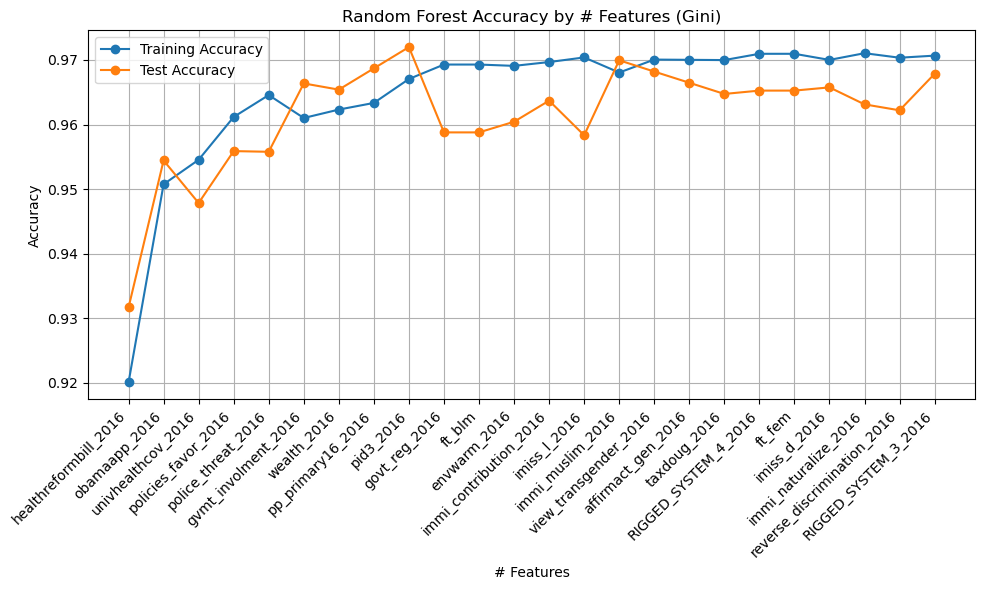

In [8]:
#refit RF with different numbers of selected features

#initialize variables for the loop
featurecount = list(range(1, 25))
train_accuracies = []
test_accuracies = []

#loop over varying numbers of features
for i in featurecount:
    #read inital df each time and drop rows after selecting variables
    dat_fs = pd.read_parquet('data/votersurvey_cleaned_noDropNA.parquet') 
    featurestokeep = selectedfeatures_gini[0:i].copy()
    featurestokeep.loc['1'] = 'presvote16post_2016' #add target variable to selected features
    dat_fs = dat_fs.filter(items=featurestokeep) #filter for only selected variables
    dat_fs = dat_fs.dropna()
    
    #prepare data
    y = dat_fs["presvote16post_2016"]
    X = dat_fs.drop(columns = "presvote16post_2016")
    #one-hot encode categorical data
    X_oh = pd.get_dummies(X, dtype = int)
    X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)


    #fit rf
    rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = selectedmaxdepth)
    rf.fit(X_train_oh, y_train)


    # Store accuracies
    train_acc = rf.score(X_train_oh, y_train)
    test_acc = rf.score(X_test_oh, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    '# Features': featurecount,
    'train_accuracy': train_accuracies,
    'Feature Names': selectedfeatures_gini[:len(featurecount)],  # Get corresponding feature names
    'test_accuracy': test_accuracies
})

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(results_df['# Features'], results_df['train_accuracy'],
         marker='o', label='Training Accuracy')
plt.plot(results_df['# Features'], results_df['test_accuracy'],
         marker='o', label='Test Accuracy')
plt.xlabel('# Features')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy by # Features (Gini)')
plt.legend()
plt.grid(True)

# Set custom x-tick labels
plt.xticks(ticks=featurecount, labels=results_df['Feature Names'], rotation=45, ha='right')
plt.tight_layout()  # Adjust layout to prevent label cutoff


#save figure
plt.savefig(f'results/RF/RF_performance_by_number_of_features_gini_maxdepth{selectedmaxdepth}.png')
plt.show()


    

### feature importance using permutation importance

In [9]:
#feature importance based on permutation importance
#this takes a few minutes to run

from sklearn.inspection import permutation_importance

# run random forest with preferred depth and create confusion matrix
rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = selectedmaxdepth)
rf.fit(X_train_oh, y_train)

result = permutation_importance(
    rf, X_test_oh, y_test, random_state=42, n_jobs=-1
)

In [10]:
#create df
imp = result.importances_mean
imp_names = rf.feature_names_in_
permutation_importances = pd.DataFrame({"imp_names" : imp_names, "imp" : imp})

# Extract the base name (everything before the last underscore)
permutation_importances["base_name"] = permutation_importances["imp_names"].str.rsplit('_', n=1).str[0]

# Group by base_name and sum the 'imp' values
permutation_importances_grouped = permutation_importances.groupby("base_name", as_index=False)["imp"].sum().sort_values("imp", ascending = False)
permutation_importances_grouped = permutation_importances_grouped.rename(columns = {"imp": "imp_grouped"})

#display grouped permutation importances
permutation_importances_grouped.head(25)

,base_name,imp_grouped
12,obamaapp_2016,0.005387
6,healthreformbill_2016,0.002085
15,policies_favor_2016,0.001216
14,police_threat_2016,0.001043
16,pp_primary16_2016,0.000521
17,reverse_discrimination_2016,-0.000174
18,taxdoug_2016,-0.000348
5,gvmt_involment_2016,-0.000521
0,RIGGED_SYSTEM_3_2016,-0.000695
2,affirmact_gen_2016,-0.000695


In [11]:
#display individual permutaiton importances
permutation_importances.sort_values('imp', ascending = False).head(25)

,imp_names,imp,base_name
8,obamaapp_2016_Strongly Disapprove,0.005213,obamaapp_2016
3,healthreformbill_2016_Repealed,0.003997,healthreformbill_2016
13,policies_favor_2016_Favor blacks over whites,0.001738,policies_favor_2016
18,police_threat_2016_Part of a broader pattern,0.001043,police_threat_2016
5,obamaapp_2016_Somewhat Approve,0.000695,obamaapp_2016
26,pp_primary16_2016_In the Republican primary,0.000348,pp_primary16_2016
6,obamaapp_2016_Somewhat Disapprove,0.000174,obamaapp_2016
25,pp_primary16_2016_In the Democratic primary,0.000174,pp_primary16_2016
4,obamaapp_2016_Don't know,0.000000,obamaapp_2016
19,gvmt_involment_2016_Don't know,0.000000,gvmt_involment_2016


### fit random forest using the feature selection based on permutation importances

In [12]:
#isolate top 25 features
selectedfeatures_perm = permutation_importances_grouped['base_name'].head(25)
selectedfeatures_perm.to_csv('data/selectedfeautures_permutation.csv')
selectedfeatures_perm

12                  obamaapp_2016
6           healthreformbill_2016
15            policies_favor_2016
14             police_threat_2016
16              pp_primary16_2016
17    reverse_discrimination_2016
18                   taxdoug_2016
5             gvmt_involment_2016
0            RIGGED_SYSTEM_3_2016
2              affirmact_gen_2016
7                    imiss_d_2016
11           immi_naturalize_2016
8                    imiss_l_2016
21                    wealth_2016
10               immi_muslim_2016
1            RIGGED_SYSTEM_4_2016
19             univhealthcov_2016
20          view_transgender_2016
4                   govt_reg_2016
3                    envwarm_2016
9          immi_contribution_2016
13                      pid3_2016
Name: base_name, dtype: str

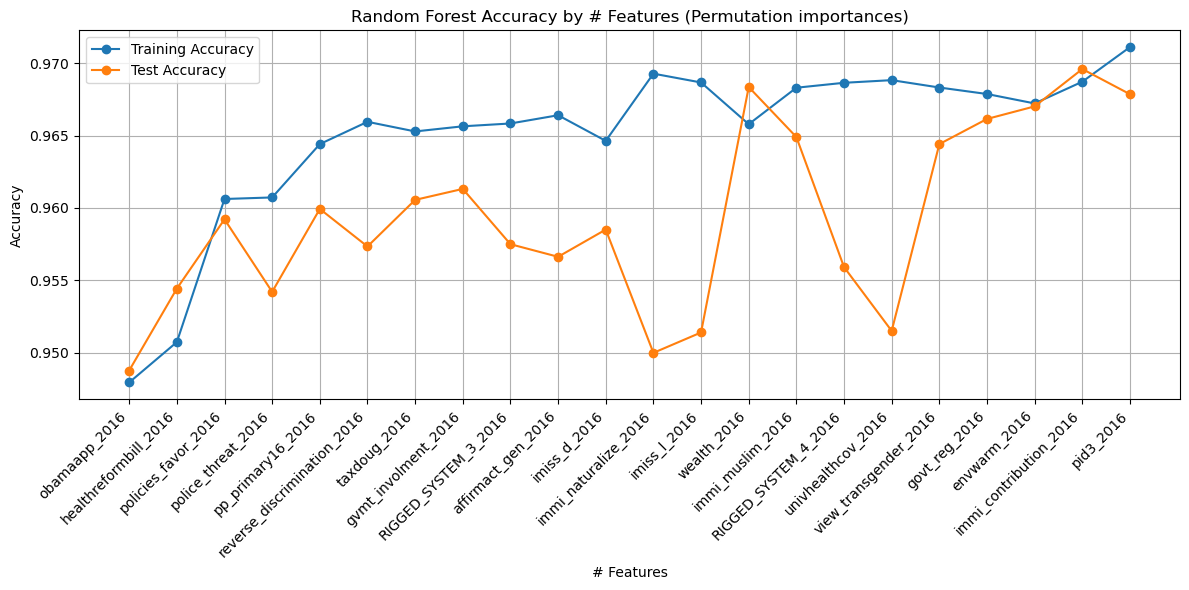

In [14]:
#refit RF with different numbers of selected features

#initialize variables for the loop
featurecount = list(range(1, 23))
train_accuracies = []
test_accuracies = []

#loop over varying numbers of features
for i in featurecount:
    #read inital df each time and drop rows after selecting variables
    dat_fs = pd.read_parquet('data/votersurvey_cleaned_noDropNA.parquet') 
    featurestokeep = selectedfeatures_perm[0:i].copy() 
    featurestokeep.loc['1'] = 'presvote16post_2016' #add target variable to selected features
    dat_fs = dat_fs.filter(items=featurestokeep) #filter for only selected variables
    dat_fs = dat_fs.dropna()
    
    #prepare data
    y = dat_fs["presvote16post_2016"]
    X = dat_fs.drop(columns = "presvote16post_2016")
    #one-hot encode categorical data
    X_oh = pd.get_dummies(X, dtype = int)
    X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)


    #fit rf
    rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = selectedmaxdepth)
    rf.fit(X_train_oh, y_train)


    # Store accuracies
    train_acc = rf.score(X_train_oh, y_train)
    test_acc = rf.score(X_test_oh, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    '# Features': featurecount,
    'Feature Names': selectedfeatures_perm[:len(featurecount)],  # Get corresponding feature names
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(results_df['# Features'], results_df['train_accuracy'],
         marker='o', label='Training Accuracy')
plt.plot(results_df['# Features'], results_df['test_accuracy'],
         marker='o', label='Test Accuracy')
plt.xlabel('# Features')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy by # Features (Permutation importances)')
plt.legend()
plt.grid(True)

# Set custom x-tick labels
plt.xticks(ticks=featurecount, labels=results_df['Feature Names'], rotation=45, ha='right')
plt.tight_layout()  # Adjust layout to prevent label cutoff

#save figure
plt.savefig(f'results/RF/RF_performance_by_number_of_features_permutation_maxdepth{selectedmaxdepth}.png')
plt.show()


### fit random forest using the feature selection based on cramers V from the featureselection notebook

In [19]:
selectedfeatures_cramer = pd.read_csv('data/df_top25_cramersv.csv')
selectedfeatures_cramer = selectedfeatures_cramer.columns.tolist()
selectedfeatures_cramer

['obamaapp_2016',
 'healthreformbill_2016',
 'univhealthcov_2016',
 'ft_blm_2016',
 'policies_favor_2016',
 'imiss_l_2016',
 'envwarm_2016',
 'immi_muslim_2016',
 'pid3_2016',
 'pp_primary16_2016',
 'ideo5_2016',
 'govt_reg_2016',
 'immi_contribution_2016',
 'wealth_2016',
 'gvmt_involment_2016',
 'ft_fem_2016',
 'police_threat_2016',
 'reverse_discrimination_2016',
 'RIGGED_SYSTEM_4_2016',
 'affirmact_gen_2016',
 'race_slave_2016',
 'race_overcome_2016',
 'view_transgender_2016',
 'RIGGED_SYSTEM_3_2016',
 'ft_unions_2016',
 'presvote16post_2016']

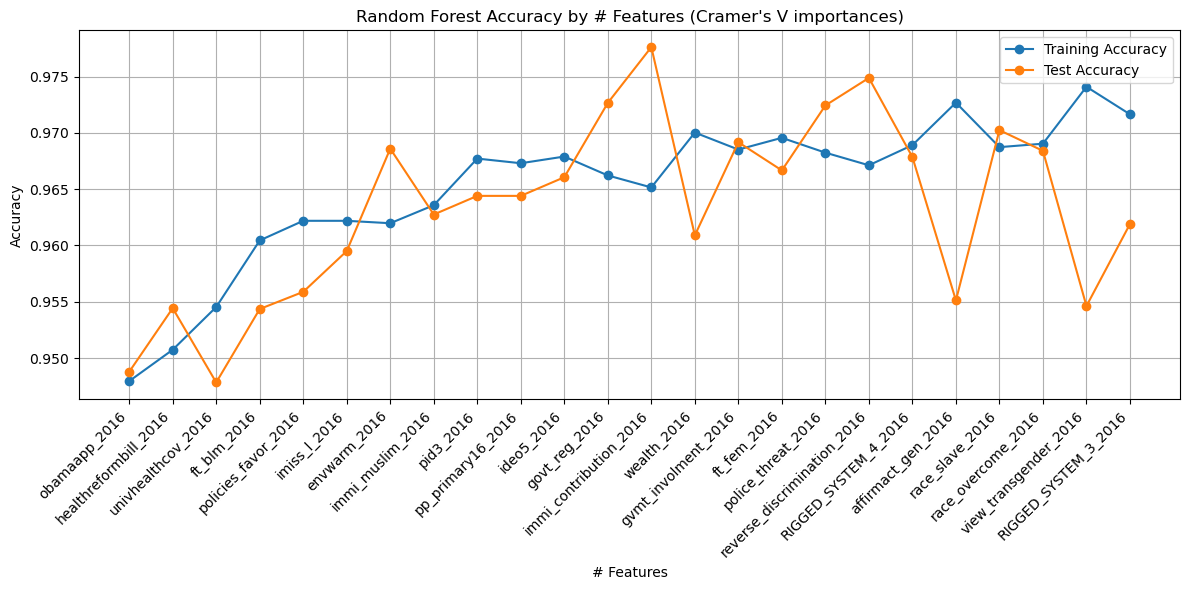

In [20]:
#refit RF with different numbers of selected features

#initialize variables for the loop
featurecount = list(range(1, 25))
train_accuracies = []
test_accuracies = []

#loop over varying numbers of features
for i in featurecount:
    #read inital df each time and drop rows after selecting variables
    dat_fs = pd.read_parquet('data/votersurvey_cleaned_noDropNA.parquet') 
    featurestokeep = selectedfeatures_cramer[0:i].copy() 
    featurestokeep.append('presvote16post_2016') #add target variable to selected features
    dat_fs = dat_fs.filter(items=featurestokeep) #filter for only selected variables
    dat_fs = dat_fs.dropna()
    
    #prepare data
    y = dat_fs["presvote16post_2016"]
    X = dat_fs.drop(columns = "presvote16post_2016")
    #one-hot encode categorical data
    X_oh = pd.get_dummies(X, dtype = int)
    X_train_oh, X_test_oh, y_train, y_test = train_test_split(X_oh, y, test_size=0.2, random_state=431)


    #fit rf
    rf = RandomForestClassifier(n_estimators = 1000, random_state = 45, max_depth = selectedmaxdepth)
    rf.fit(X_train_oh, y_train)


    # Store accuracies
    train_acc = rf.score(X_train_oh, y_train)
    test_acc = rf.score(X_test_oh, y_test)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Create DataFrame for plotting
results_df = pd.DataFrame({
    '# Features': featurecount,
    'Feature Names': selectedfeatures_cramer[:len(featurecount)],  # Get corresponding feature names
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(results_df['# Features'], results_df['train_accuracy'],
         marker='o', label='Training Accuracy')
plt.plot(results_df['# Features'], results_df['test_accuracy'],
         marker='o', label='Test Accuracy')
plt.xlabel('# Features')
plt.ylabel('Accuracy')
plt.title('Random Forest Accuracy by # Features (Cramer\'s V importances)')
plt.legend()
plt.grid(True)

# Set custom x-tick labels
plt.xticks(ticks=featurecount, labels=results_df['Feature Names'], rotation=45, ha='right')
plt.tight_layout()  # Adjust layout to prevent label cutoff

#save figure
plt.savefig(f'results/RF/RF_performance_by_number_of_features_cramersV_maxdepth{selectedmaxdepth}.png')
plt.show()
